In [129]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
print("ok")

ok


In [130]:
!pip install imbalanced-learn

In [131]:
sampling_strategy=0.1

In [132]:
df=pd.read_csv("creditcard.csv")

In [133]:
df.head(7)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
5,2.0,-0.425966,0.960523,1.141109,-0.168252,0.420987,-0.029728,0.476201,0.260314,-0.568671,...,-0.208254,-0.559825,-0.026398,-0.371427,-0.232794,0.105915,0.253844,0.081080,3.67,0
6,4.0,1.229658,0.141004,0.045371,1.202613,0.191881,0.272708,-0.005159,0.081213,0.464960,...,-0.167716,-0.270710,-0.154104,-0.780055,0.750137,-0.257237,0.034507,0.005168,4.99,0


In [134]:
print("rows:", df.shape[0])

rows: 284807


In [135]:
print("columns:", df.shape[1])

columns: 31


In [136]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [137]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [138]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [139]:
df.isnull().sum()


Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [140]:
df.duplicated().sum()

np.int64(1081)

In [141]:
df['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [142]:
class_percentage = df['Class'].value_counts(normalize=True) * 100

print(class_percentage)
#class_percentage

Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


([<matplotlib.axis.XTick at 0x28eb265d950>,
 [Text(0, 0, 'Genuine'), Text(1, 0, 'Fraudulent')])

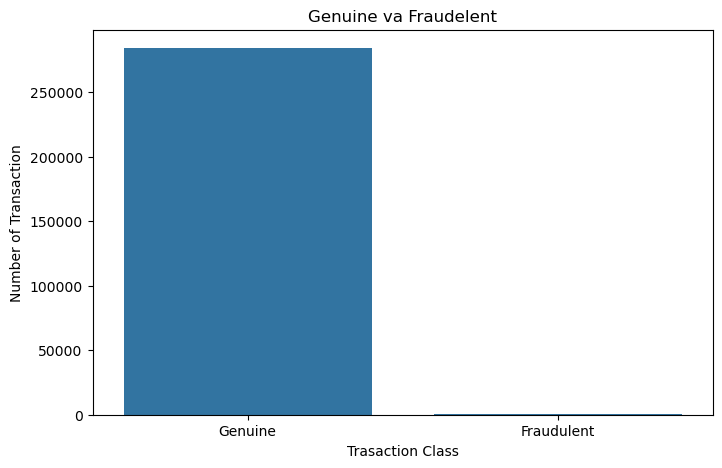

In [143]:
# Visualizeing the genuine vs fraudulent transactions
plt.figure(figsize=(8,5))
sns.countplot(x='Class',data=df)
plt.title('Genuine va Fraudelent')
plt.xlabel('Trasaction Class')
plt.ylabel('Number of Transaction')
plt.xticks([0,1],['Genuine','Fraudulent'])
           #plt.show()

Text(0.5, 1.0, 'Transaction Class Distribution')

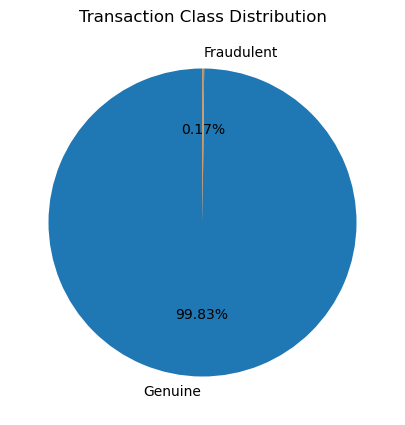

In [144]:
# Display class distribution with percentages
labels=['Genuine','Fraudulent']
values=df['Class'].value_counts().sort_index()
plt.figure(figsize=(7,5))
plt.pie(
    values,
    labels=labels,
    autopct='%1.2f%%',
    startangle=90
)
plt.title('Transaction Class Distribution')

In [145]:
# Removeing the exact duplicate rows
df_clean = df.drop_duplicates().copy()
print("Original dataset shape:", df.shape)
print("Dataset shape after removing duplicates:", df_clean.shape)
print("Duplicates remaining:", df_clean.duplicated().sum())

Original dataset shape: (284807, 31)
Dataset shape after removing duplicates: (283726, 31)
Duplicates remaining: 0


In [146]:
class_counts_clean=df_clean['Class'].value_counts()
print(class_counts_clean)
print("\nClass percentages:")
print(df_clean['Class'].value_counts(normalize=True)*100)

Class
0    283253
1       473
Name: count, dtype: int64

Class percentages:
Class
0    99.83329
1     0.16671
Name: proportion, dtype: float64


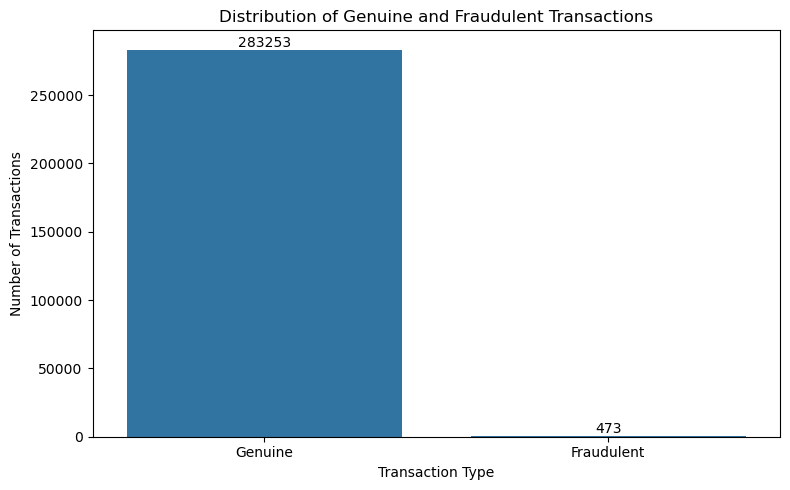

In [147]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(
    x='Class',
    data=df_clean)
plt.title('Distribution of Genuine and Fraudulent Transactions')
plt.xlabel('Transaction Type')
plt.ylabel('Number of Transactions')
plt.xticks(
    [0, 1],
    ['Genuine', 'Fraudulent'])
#Adding counts labels above bars
for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

In [148]:
df_clean.shape

(283726, 31)

In [149]:
df_clean.groupby('Class')['Amount'].describe()

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,283253.0,88.413575,250.379023,0.0,5.67,22.00,77.46,25691.16
1,473.0,123.871860,260.211041,0.0,1.00,9.82,105.89,2125.87


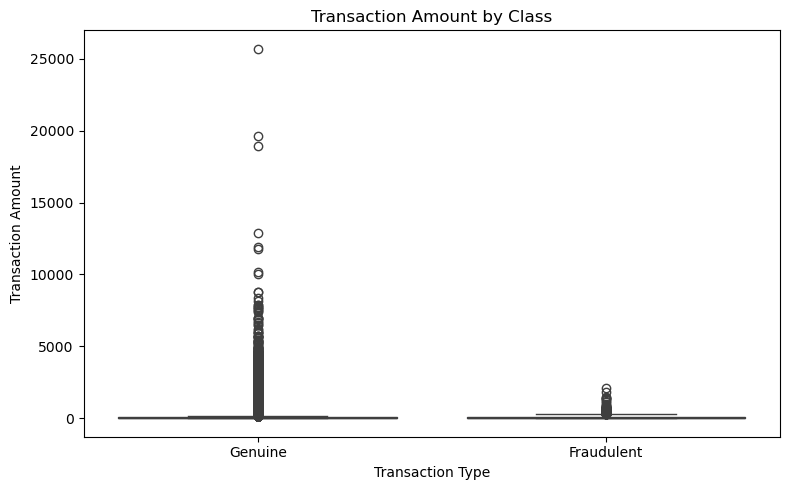

In [150]:
# Compareing the transaction amounts between genuine and fraudulent transactions
plt.figure(figsize=(8, 5))
sns.boxplot(
    x='Class',
    y='Amount',
    data=df_clean)
plt.title('Transaction Amount by Class')
plt.xlabel('Transaction Type')
plt.ylabel('Transaction Amount')
plt.xticks(
    [0, 1],
    ['Genuine', 'Fraudulent'])

plt.tight_layout()
plt.show()

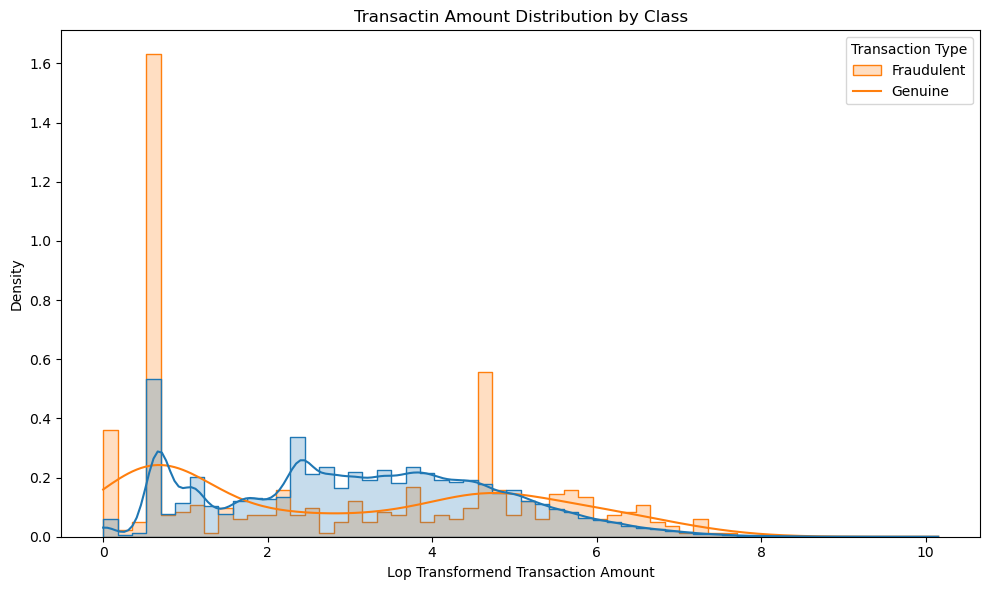

In [151]:
df_clean['Amount_log'] = np.log1p(df_clean['Amount'])
plt.figure(figsize=(10,6))
sns.histplot(data=df_clean,
             x='Amount_log',
             hue='Class',
             bins=58,
             kde=True,
             element='step',
             stat='density',
             common_norm=False)
plt.title('Transactin Amount Distribution by Class')
plt.xlabel('Lop Transformend Transaction Amount')
plt.ylabel('Density')
plt.legend(
    title='Transaction Type',
    labels=['Fraudulent','Genuine'])
plt.tight_layout()
plt.show()

In [152]:
# Convert transaction time from seconds to hours
# This is used for easier interpretation during EDA
df_clean['Time_hours'] = df_clean['Time'] / 3600
print("Minimum time (hours):", df_clean['Time_hours'].min())
print("Maximum time (hours):", df_clean['Time_hours'].max())

Minimum time (hours): 0.0
Maximum time (hours): 47.99777777777778


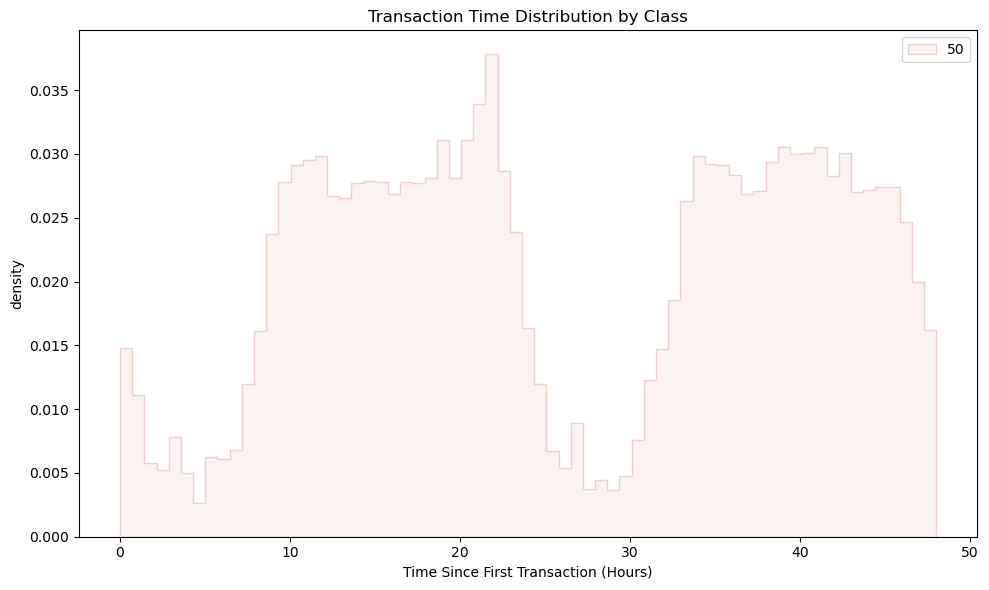

In [153]:
# Visualize transaction time distribution by class
plt.figure(figsize=(10,6))
sns.histplot(
    data=df_clean,
    x='Time_hours',
    hue=50,
    element='step',
    stat='density',
    common_norm=False)
plt.title('Transaction Time Distribution by Class')
plt.ylabel('density')
plt.xlabel('Time Since First Transaction (Hours)')
plt.tight_layout()
plt.show()

In [154]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    roc_curve,
    f1_score,
    precision_score,
    recall_score)


In [155]:
from xgboost import XGBClassifier
X = df.drop('Class', axis=1)
y = df['Class']
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y)
print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)
print("\nTraining class distribution:")
print(y_train.value_counts())
print("\nTesting class distribution:")
print(y_test.value_counts())

Training set: (227845, 30)
Testing set: (56962, 30)

Training class distribution:
Class
0    227451
1       394
Name: count, dtype: int64

Testing class distribution:
Class
0    56864
1       98
Name: count, dtype: int64


In [156]:
smote = SMOTE(
    sampling_strategy=0.1,
    random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train)
print("Before SMOTE:")
print(y_train.value_counts())
print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

Before SMOTE:
Class
0    227451
1       394
Name: count, dtype: int64

After SMOTE:
Class
0    227451
1     22745
Name: count, dtype: int64


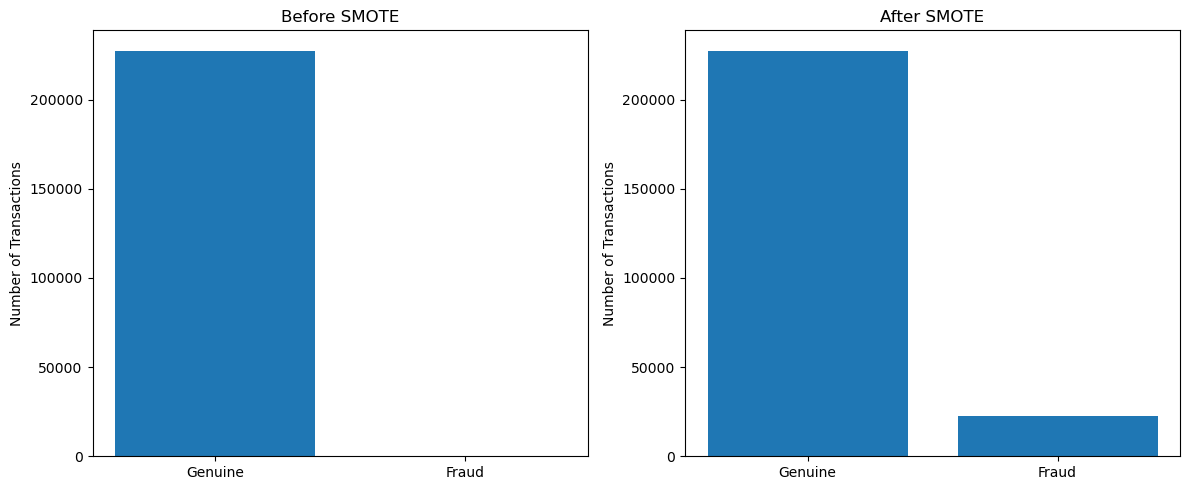

In [157]:
before = y_train.value_counts().sort_index()
after = y_train_smote.value_counts().sort_index()
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].bar(
    ['Genuine', 'Fraud'],
    before.values)
axes[0].set_title('Before SMOTE')
axes[0].set_ylabel('Number of Transactions')
axes[1].bar(
    ['Genuine', 'Fraud'],
    after.values)
axes[1].set_title('After SMOTE')
axes[1].set_ylabel('Number of Transactions')
plt.tight_layout()
plt.show()

In [158]:
scaler = StandardScaler()
X_train_lr = scaler.fit_transform(X_train_smote)
X_test_lr = scaler.transform(X_test)

In [159]:
scaler.fit_transform(X_train_smote)

array([[ 1.42984347e+00,  7.79179338e-01, -4.83268413e-01, ...,
         1.17999938e-01, -1.15020775e-01, -3.35627062e-01],
       [ 6.43929768e-01,  8.08129264e-01, -1.70449829e-01, ...,
        -2.26785679e-02, -2.21775514e-01, -3.53186344e-01],
       [-1.10425700e+00, -1.83170742e-01,  1.19441228e-01, ...,
         4.38559789e-02,  5.16981456e-01,  3.44764705e-01],
       ...,
       [-1.10174701e+00, -3.70947062e+00,  2.94411144e+00, ...,
        -1.55343120e+00, -2.29552190e+00,  8.53964457e-01],
       [ 8.97434089e-04, -1.42786351e+00,  2.69882661e+00, ...,
         1.33365429e+00,  1.77851402e+00, -2.88016400e-01],
       [ 1.03405602e+00,  3.47814205e-01,  5.42977429e-01, ...,
         3.44136185e-01,  3.78698763e-01, -3.64257556e-01]],
      shape=(250196, 30))

In [160]:
scaler.transform(X_test)

array([[ 1.40551587, -0.07921151,  0.47727987, ...,  0.97231585,
         0.82480586, -0.27204056],
       [-1.55227105, -0.78504229, -1.37801725, ...,  0.18010017,
        -1.50832035, -0.31725673],
       [-0.11488564, -1.02956358,  0.88197785, ...,  1.00709906,
         1.45929503, -0.05682784],
       ...,
       [ 1.51697364, -0.20144642,  0.15587293, ...,  0.00508886,
         0.40019672, -0.29884584],
       [ 1.46909508,  0.84900606, -0.63073533, ..., -0.03220147,
        -0.18623721, -0.28440911],
       [-0.89710507,  0.54382446, -0.41691139, ...,  0.01903588,
         0.12437934, -0.12240141]], shape=(56962, 30))

In [161]:
lr_smote = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_smote.fit(
    X_train_lr,
    y_train_smote
)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [162]:
y_pred_lr = lr_smote.predict(X_test_lr)
y_prob_lr = lr_smote.predict_proba(X_test_lr)[:, 1]

In [163]:
print("Logistic Regression + SMOTE")

print(classification_report(y_test, y_pred_lr))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))

print("ROC-AUC:",
      roc_auc_score(y_test, y_prob_lr))

print("PR-AUC:",
      average_precision_score(y_test, y_prob_lr))

Logistic Regression + SMOTE
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.52      0.88      0.65        98

    accuracy                           1.00     56962
   macro avg       0.76      0.94      0.83     56962
weighted avg       1.00      1.00      1.00     56962

Confusion Matrix:
[[56784    80]
 [   12    86]]
ROC-AUC: 0.9739644644436277
PR-AUC: 0.7183267411420463


In [164]:
print("Logistic Regression + SMOTE")

print(classification_report(y_test, y_pred_lr))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))

print("ROC-AUC:",
      roc_auc_score(y_test, y_prob_lr))

print("PR-AUC:",
      average_precision_score(y_test, y_prob_lr))

Logistic Regression + SMOTE
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.52      0.88      0.65        98

    accuracy                           1.00     56962
   macro avg       0.76      0.94      0.83     56962
weighted avg       1.00      1.00      1.00     56962

Confusion Matrix:
[[56784    80]
 [   12    86]]
ROC-AUC: 0.9739644644436277
PR-AUC: 0.7183267411420463


In [165]:
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_test: (56962, 30)
y_test: (56962,)


In [166]:
print("y_test length:", len(y_test))
print("y_pred_rf length:", len(y_pred_rf))

y_test length: 56962
y_pred_rf length: 56962


In [167]:
from sklearn.model_selection import train_test_split

X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("\nTraining classes:")
print(y_train.value_counts())

print("\nTesting classes:")
print(y_test.value_counts())

X_train: (227845, 30)
X_test: (56962, 30)

Training classes:
Class
0    227451
1       394
Name: count, dtype: int64

Testing classes:
Class
0    56864
1       98
Name: count, dtype: int64


In [168]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(
    sampling_strategy=0.1,
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

Before SMOTE:
Class
0    227451
1       394
Name: count, dtype: int64

After SMOTE:
Class
0    227451
1     22745
Name: count, dtype: int64


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_smote = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_smote.fit(
    X_train_smote,
    y_train_smote
)

In [ ]:
y_pred_rf = rf_smote.predict(X_test)

y_prob_rf = rf_smote.predict_proba(X_test)[:, 1]

In [ ]:
print("y_test:", len(y_test))
print("y_pred_rf:", len(y_pred_rf))

In [ ]:
print("Random Forest + SMOTE")

print(classification_report(y_test, y_pred_rf))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("ROC-AUC:",
      roc_auc_score(y_test, y_prob_rf))

print("PR-AUC:",
      average_precision_score(y_test, y_prob_rf))

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, average_precision_score

# Scale the data
scaler_smote = StandardScaler()

X_train_smote_scaled = scaler_smote.fit_transform(X_train_smote)
X_test_scaled = scaler_smote.transform(X_test)

# Train Logistic Regression
lr_smote = LogisticRegression(
    random_state=42,
    max_iter=1000
)

lr_smote.fit(X_train_smote_scaled, y_train_smote)

# Predictions
y_pred_lr_smote = lr_smote.predict(X_test_scaled)
y_prob_lr_smote = lr_smote.predict_proba(X_test_scaled)[:, 1]

# Evaluation
print("Logistic Regression + SMOTE")
print(classification_report(y_test, y_pred_lr_smote))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr_smote))

print("ROC-AUC:", roc_auc_score(y_test, y_prob_lr_smote))
print("PR-AUC:", average_precision_score(y_test, y_prob_lr_smote))

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import roc_auc_score, average_precision_score

# Train XGBoost on SMOTE training data
xgb_smote = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1
)

xgb_smote.fit(X_train_smote, y_train_smote)

# Predictions on ORIGINAL untouched test data
y_pred_xgb_smote = xgb_smote.predict(X_test)
y_prob_xgb_smote = xgb_smote.predict_proba(X_test)[:, 1]

# Evaluation
print("XGBoost + SMOTE")
print(classification_report(y_test, y_pred_xgb_smote))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb_smote))

print("ROC-AUC:", roc_auc_score(y_test, y_prob_xgb_smote))
print("PR-AUC:", average_precision_score(y_test, y_prob_xgb_smote))

In [ ]:
import pandas as pd

# Calculate metrics for all SMOTE models

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression + SMOTE",
        "Random Forest + SMOTE",
        "XGBoost + SMOTE"
    ],
    
    "Precision": [
        precision_score(y_test, y_pred_lr_smote),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_xgb_smote)
    ],
    
    "Recall": [
        recall_score(y_test, y_pred_lr_smote),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_xgb_smote)
    ],
    
    "F1-Score": [
        f1_score(y_test, y_pred_lr_smote),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_xgb_smote)
    ],
    
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_lr_smote),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_xgb_smote)
    ],
    
    "PR-AUC": [
        average_precision_score(y_test, y_prob_lr_smote),
        average_precision_score(y_test, y_prob_rf),
        average_precision_score(y_test, y_prob_xgb_smote)
    ]
})

comparison = comparison.round(4)

print(comparison)

In [ ]:
import matplotlib.pyplot as plt

comparison.set_index("Model")[["Precision", "Recall", "F1-Score"]].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("SMOTE Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

models = [
    ("Logistic Regression + SMOTE", y_pred_lr_smote),
    ("Random Forest + SMOTE", y_pred_rf),
    ("XGBoost + SMOTE", y_pred_xgb_smote)
]

for name, predictions in models:
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        predictions
    )
    plt.title(name)
    plt.tight_layout()
    plt.show()

In [ ]:
from sklearn.metrics import PrecisionRecallDisplay

plt.figure(figsize=(9, 6))

PrecisionRecallDisplay.from_predictions(
    y_test,
    y_prob_lr_smote,
    name="Logistic Regression + SMOTE"
)

PrecisionRecallDisplay.from_predictions(
    y_test,
    y_prob_rf,
    name="Random Forest + SMOTE"
)

PrecisionRecallDisplay.from_predictions(
    y_test,
    y_prob_xgb_smote,
    name="XGBoost + SMOTE"
)

plt.title("Precision-Recall Curve")
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import RocCurveDisplay

plt.figure(figsize=(9, 6))

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_lr_smote,
    name="Logistic Regression + SMOTE"
)

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_rf,
    name="Random Forest + SMOTE"
)

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_xgb_smote,
    name="XGBoost + SMOTE"
)

plt.title("ROC Curve Comparison")
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import RocCurveDisplay

plt.figure(figsize=(9, 6))

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_lr_smote,
    name="Logistic Regression + SMOTE"
)

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_rf,
    name="Random Forest + SMOTE"
)

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_xgb_smote,
    name="XGBoost + SMOTE"
)

plt.title("ROC Curve Comparison")
plt.tight_layout()
plt.show()

In [ ]:
# FINAL MODEL PERFORMANCE SUMMARY

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)
import pandas as pd

results = []

models_data = [
    ("Logistic Regression + SMOTE", y_pred_lr_smote, y_prob_lr_smote),
    ("Random Forest + SMOTE", y_pred_rf, y_prob_rf),
    ("XGBoost + SMOTE", y_pred_xgb_smote, y_prob_xgb_smote)
]

for name, y_pred, y_prob in models_data:
    results.append({
        "Model": name,
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob),
        "PR-AUC": average_precision_score(y_test, y_prob)
    })

final_results = pd.DataFrame(results).round(4)

print("FINAL MODEL COMPARISON")
display(final_results)

print("\nBest Model by F1-Score:")
print(final_results.loc[final_results["F1-Score"].idxmax(), "Model"])

print("\nBest Model by PR-AUC:")
print(final_results.loc[final_results["PR-AUC"].idxmax(), "Model"])

print("\nBest Model by ROC-AUC:")
print(final_results.loc[final_results["ROC-AUC"].idxmax(), "Model"])

In [ ]:
import joblib

# Save final Random Forest + SMOTE model
joblib.dump(rf_smote, "credit_card_fraud_random_forest_smote.pkl")

# Save feature names
joblib.dump(list(X_train.columns), "credit_card_fraud_feature_names.pkl")

print("Final Random Forest + SMOTE model saved successfully!")

In [ ]:
# Divide transactions into time intervals
# and calculate the fraud rate for each interval
df_clean['Time_bin'] = pd.cut(
    df_clean['Time_hours'],
    bins=20)
fraud_rate_by_time = df_clean.groupby(
    'Time_bin',
    observed=False
)['Class'].mean() * 100
fraud_rate_by_time

In [ ]:
# Plot fraud rate over time
plt.figure(figsize=(12, 6))
fraud_rate_by_time.plot(
    kind='line',
    marker='o')
plt.title('Fraud Rate Across Transaction Time')
plt.xlabel('Transaction Time Interval')
plt.ylabel('Fraud Rate (%)')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
v_features=[f'V{i}' for i in range(1,29)]
print('Number of V features:',len(v_features))
print(v_features)

In [ ]:
# Calculateing the mean of each V feature for genuine and fraudulent transactions
feature_means = df_clean.groupby('Class')[v_features].mean().T
feature_means.columns = ['Genuine', 'Fraudulent']
feature_means['Absolute_Difference'] = (
    feature_means['Fraudulent'] - feature_means['Genuine']
).abs()
feature_means.sort_values(
    'Absolute_Difference',
    ascending=False
).head(10)

In [ ]:
# Selecting the 10 features with the largest mean difference
top_features = feature_means.sort_values(
    'Absolute_Difference',
    ascending=False
).head(10)
top_features[['Genuine', 'Fraudulent']].plot(
    kind='bar',
    figsize=(12, 6))
plt.title('Top 10 V Features: Genuine vs Fraudulent Transactions')
plt.xlabel('Feature')
plt.ylabel('Mean Feature Value')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Identify the feature with the largest difference in class means
top_feature = top_features.index[0]
print("Most different feature:", top_feature)

In [ ]:
# Compareing the distribution of the most different feature
plt.figure(figsize=(10, 6))
sns.histplot(
    data=df_clean,
    x=top_feature,
    hue='Class',
    bins=50,
    stat='density',
    common_norm=False,
    element='step',
    kde=True
)
plt.title(f'{top_feature} Distribution: Genuine vs Fraudulent')
plt.xlabel(top_feature)
plt.ylabel('Density')
plt.tight_layout()
plt.show()

In [ ]:
# Selecting the top 6 features based on mean difference
top_6_features = top_features.head(6).index.tolist()
print("Top 6 features:")
print(top_6_features)

In [ ]:
# Create boxplots for the top 6 features
for feature in top_6_features:
    plt.figure(figsize=(8, 5))
    sns.boxplot(
        x='Class',
        y=feature,
        data=df_clean)
    plt.title(f'{feature} Distribution by Transaction Class')
    plt.xlabel('Transaction Type')
    plt.ylabel(feature)
    
    plt.xticks(
        [0, 1],
        ['Genuine', 'Fraudulent'])
    
    plt.tight_layout()
    plt.show()

In [ ]:
# Createing the feature matrix (X) and target variable (y)
# Removeing EDA-only columns
model_df = df_clean.drop(
    columns=['Amount_log', 'Time_hours', 'Time_bin'])
# Features
X = model_df.drop(columns=['Class'])
y = model_df['Class']
print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y)
print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)
print("\nTraining class distribution:")
print(y_train.value_counts())
print("\nTesting class distribution:")
print(y_test.value_counts())

In [ ]:
from sklearn.preprocessing import StandardScaler
# Createing the scaler
scaler = StandardScaler()
# Fit the scaler ONLY on the training data
X_train_scaled = scaler.fit_transform(X_train)
# Useing the same scaler to transform the test data
X_test_scaled = scaler.transform(X_test)
print("Training data shape:", X_train_scaled.shape)
print("Testing data shape:", X_test_scaled.shape)

In [ ]:
from sklearn.linear_model import LogisticRegression
# Createing Logistic Regression model
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42)
# Train the model
logistic_model.fit(X_train_scaled, y_train)
print("Logistic Regression model trained successfully!")

In [ ]:
# Predicting the class labels for the test set
y_pred_logistic = logistic_model.predict(X_test_scaled)
print("Predictions generating successfully!")

In [ ]:
# Get probability of the fraudulent class
y_prob_logistic = logistic_model.predict_proba(X_test_scaled)[:, 1]
print("First 13 fraud probabilities:")
print(y_prob_logistic[:13])

In [ ]:
from sklearn.metrics import classification_report
print('Logistic Regressin-Classification Report')
print(classification_report(y_test,y_pred_logistic))

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred_logistic)
print("Confusion Matrix:")
print(cm)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Genuine', 'Fraudulent'])
disp.plot()
plt.title('Logistic Regression - Confusion Matrix')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve
roc_auc = roc_auc_score(
    y_test,
    y_prob_logistic)
print("Logistic Regression ROC-AUC:", roc_auc)

In [ ]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob_logistic)
plt.figure(figsize=(8, 6))
plt.plot(
    fpr,
    tpr,
    label=f'Logistic Regression (AUC = {roc_auc:.4f})')
plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score
precision, recall, thresholds = precision_recall_curve(
    y_test,
    y_prob_logistic)
pr_auc = average_precision_score(
    y_test,
    y_prob_logistic)
print("Logistic Regression PR-AUC:", pr_auc)

In [ ]:
plt.figure(figsize=(8, 6))
plt.plot(
    recall,
    precision,
    label=f'Logistic Regression (AP = {pr_auc:.4f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - Logistic Regression')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Logistic Regression with class weighting
# This gives us more importance to the minority fraud class
logistic_weighted = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight='balanced')
logistic_weighted.fit(
    X_train_scaled,
    y_train)
print("Weighted Logistic Regression trained successfully!")

In [ ]:
# Generate predictions from the weighted model
y_pred_weighted = logistic_weighted.predict(X_test_scaled)
# Generateing the fraud probabilities
y_prob_weighted = logistic_weighted.predict_proba(
    X_test_scaled
)[:, 1]
print("Predictions generated successfully!")

In [ ]:
from sklearn.metrics import classification_report
print("Weighted Logistic Regression - Classification Report")
print(classification_report(
        y_test,
        y_pred_weighted))

In [ ]:
from sklearn.metrics import confusion_matrix
cm_weighted = confusion_matrix(
    y_test,
    y_pred_weighted)
print("Confusion Matrix:")
print(cm_weighted)

In [ ]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score)
roc_auc_weighted = roc_auc_score(
    y_test,
    y_prob_weighted)
pr_auc_weighted = average_precision_score(
    y_test,
    y_prob_weighted)
print("Weighted Logistic Regression")
print("ROC-AUC:", roc_auc_weighted)
print("PR-AUC :", pr_auc_weighted)

In [ ]:
# Train Logistic Regression with balanced class weights
logistic_weighted = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight='balanced')
logistic_weighted.fit(X_train_scaled, y_train)
print("Weighted Logistic Regression trained successfully!")

In [ ]:
# Generateing predictions and fraud probabilities
y_pred_weighted = logistic_weighted.predict(X_test_scaled)
y_prob_weighted = logistic_weighted.predict_proba(
    X_test_scaled
)[:, 1]
print("Predictions generated successfully!")

In [ ]:
from sklearn.metrics import classification_report
print("Weighted Logistic Regression - Classification Report")
print(classification_report(
        y_test,
        y_pred_weighted))

In [ ]:
from sklearn.metrics import confusion_matrix
cm_weighted = confusion_matrix(
    y_test,
    y_pred_weighted)
print("Weighted Logistic Regression - Confusion Matrix")
print(cm_weighted)

In [ ]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score)
roc_auc_weighted = roc_auc_score(
    y_test,
    y_prob_weighted)
pr_auc_weighted = average_precision_score(
    y_test,
    y_prob_weighted)
print("Weighted Logistic Regression")
print("ROC-AUC:", roc_auc_weighted)
print("PR-AUC :", pr_auc_weighted)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf_model=RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1)
rf_model.fit(X_train,y_train)

print("Random Forest model trained successfully!")
print('all ok ')

In [ ]:
# Predict class labels
y_pred_rf = rf_model.predict(X_test)

# Predict fraud probabilities
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest predictions generated successfully!")

In [ ]:
from sklearn.metrics import classification_report
print('Random forest -Classification report')
print(
    classification_report(
        y_test,
        y_pred_rf))

In [ ]:
from sklearn.metrics import confusion_matrix
cm_rf = confusion_matrix(
    y_test,
    y_pred_rf)
print("Random Forest - Confusion Matrix")
print(cm_rf)

In [ ]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score)
roc_auc_rf = roc_auc_score(
    y_test,
    y_prob_rf)
pr_auc_rf = average_precision_score(
    y_test,
    y_prob_rf)
print("Random Forest")
print("ROC-AUC:", roc_auc_rf)
print("PR-AUC :", pr_auc_rf)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
# Random Forest with balanced class weights
rf_weighted = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1)
# Train the model
rf_weighted.fit(X_train, y_train)
print("Weighted Random Forest trained successfully!")

In [ ]:
# Generateingg predictions
y_pred_rf_weighted = rf_weighted.predict(X_test)
# Generate fraud probabilities
y_prob_rf_weighted = rf_weighted.predict_proba(
    X_test
)[:, 1]
print("Weighted Random Forest predictions generated successfully!")

In [ ]:
from sklearn.metrics import classification_report
print("Weighted Random Forest - Classification Report")
print(
    classification_report(
        y_test,
        y_pred_rf_weighted))

In [ ]:
from sklearn.metrics import confusion_matrix
cm_rf_weighted = confusion_matrix(
    y_test,
    y_pred_rf_weighted)
print("Weighted Random Forest - Confusion Matrix")
print(cm_rf_weighted)

In [ ]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score)
roc_auc_rf_weighted = roc_auc_score(
    y_test,
    y_prob_rf_weighted)
pr_auc_rf_weighted = average_precision_score(
    y_test,
    y_prob_rf_weighted)
print("Weighted Random Forest")
print("ROC-AUC:", roc_auc_rf_weighted)
print("PR-AUC :", pr_auc_rf_weighted)

In [ ]:
%pip install xgboost

In [ ]:
import xgboost as xgb
print("XGBoost version:", xgb.__version__)

In [ ]:
from xgboost import XGBClassifier
# Calculate the imbalance ratio
negative = y_train.value_counts()[0]
positive = y_train.value_counts()[1]
scale_pos_weight = negative / positive
print("Negative class:", negative)
print("Positive class:", positive)
print("Scale Pos Weight:", scale_pos_weight)

In [ ]:
xgb_model = XGBClassifier(
    n_estimators=150,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1)
print("XGBoost model created successfully!")

In [ ]:
xgb_model.fit(
    X_train,
    y_train)
print("XGBoost model trained successfully!")

In [ ]:
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(
    X_test
)[:, 1]
print("XGBoost predictions generated successfully!")

In [ ]:
from sklearn.metrics import classification_report
print("XGBoost - Classification Report")
print(
    classification_report(
        y_test,
        y_pred_xgb))

In [ ]:
from sklearn.metrics import confusion_matrix
cm_xgb = confusion_matrix(
    y_test,
    y_pred_xgb)
print("XGBoost - Confusion Matrix")
print(cm_xgb)

In [ ]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score)
roc_auc_xgb = roc_auc_score(
    y_test,
    y_prob_xgb)
pr_auc_xgb = average_precision_score(
    y_test,
    y_prob_xgb)
print("XGBoost")
print("ROC-AUC:", roc_auc_xgb)
print("PR-AUC :", pr_auc_xgb)

In [ ]:
from sklearn.metrics import classification_report
print("XGBoost - Classification Report")
print(
    classification_report(
        y_test,
        y_pred_xgb))

In [ ]:
from sklearn.metrics import confusion_matrix
cm_xgb = confusion_matrix(
    y_test,
    y_pred_xgb)
print("XGBoost - Confusion Matrix")
print(cm_xgb)

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds_to_test = [
    0.10,
    0.20,
    0.30,
    0.40,
    0.50,
    0.60,
    0.70,
    0.80,
    0.90
]

threshold_results = []

for threshold in thresholds_to_test:

    y_pred_threshold = (
        y_prob_xgb >= threshold
    ).astype(int)

    precision = precision_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )

    threshold_results.append([
        threshold,
        precision,
        recall,
        f1 ])
threshold_df = pd.DataFrame(
    threshold_results,
    columns=[
        'Threshold',
        'Precision',
        'Recall',
        'F1'])
threshold_df

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(
    threshold_df['Threshold'],
    threshold_df['Precision'],
    marker='o',
    label='Precision')
plt.plot(
    threshold_df['Threshold'],
    threshold_df['Recall'],
    marker='o',
    label='Recall')
plt.plot(
    threshold_df['Threshold'],
    threshold_df['F1'],
    marker='o',
    label='F1-score')
plt.xlabel('Classification Threshold')
plt.ylabel('Score')
plt.title('XGBoost Threshold Analysis')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
model_results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Weighted Logistic Regression',
        'Random Forest',
        'Weighted Random Forest',
        'XGBoost'
    ],
    'Precision': [
        0.85,
        0.056,
        0.97,
        0.97,
        0.58
    ],
    'Recall': [
        0.58,
        0.874,
        0.73,
        0.71,
        0.81
    ],
    'F1-Score': [
        0.69,
        0.105,
        0.83,
        0.82,
        0.68
    ],
    'ROC-AUC': [
        0.9560,
        0.9657,
        0.9239,
        0.9246,
        0.9753
    ],
    'PR-AUC': [
        0.6920,
        0.6719,
        0.7876,
        0.7960,
        0.7864
    ]
})

model_results

In [ ]:
plt.figure(figsize=(10, 6))
x = np.arange(len(model_results['Model']))
width = 0.2
plt.bar(
    x - width,
    model_results['Precision'],
    width,
    label='Precision')
plt.bar(
    x,
    model_results['Recall'],
    width,
    label='Recall')
plt.bar(
    x + width,
    model_results['F1-Score'],
    width,
    label='F1-Score')
plt.xticks(
    x,
    model_results['Model'],
    rotation=25,
    ha='right')
plt.ylabel('Score')
plt.title('Model Performance Comparison')
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import roc_curve, auc
# Calculate ROC curves
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_logistic)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)
# Plot ROC curves
plt.figure(figsize=(9, 6))
plt.plot(
    fpr_log,
    tpr_log,
    label=f'Logistic Regression (AUC = {roc_auc_score(y_test, y_prob_logistic):.3f})')
plt.plot(
    fpr_rf,
    tpr_rf,
    label=f'Random Forest (AUC = {roc_auc_score(y_test, y_prob_rf):.3f})')
plt.plot(
    fpr_xgb,
    tpr_xgb,
    label=f'XGBoost (AUC = {roc_auc_score(y_test, y_prob_xgb):.3f})')
# Random classifier reference line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_xgb,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Genuine', 'Fraud'],
    yticklabels=['Genuine', 'Fraud']
)

plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.title('XGBoost Confusion Matrix')

plt.tight_layout()
plt.show()

In [ ]:
# Get XGBoost feature importance
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb_model.feature_importances_
})

# Sort by importance
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

# Display top 10
print("Top 10 Most Important Features:")
display(feature_importance.head(10))

In [ ]:
plt.figure(figsize=(9, 6))

top_features = feature_importance.head(10).sort_values(
    by='Importance'
)

plt.barh(
    top_features['Feature'],
    top_features['Importance']
)

plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Top 10 XGBoost Feature Importances')

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

# Store model predictions and probabilities
models = {
    "Logistic Regression": (y_pred_logistic, y_prob_logistic),
    "Random Forest": (y_pred_rf, y_prob_rf),
    "XGBoost": (y_pred_xgb, y_prob_xgb)
}

results = []

for model_name, (predictions, probabilities) in models.items():

    precision = precision_score(
        y_test,
        predictions,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        predictions,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        predictions,
        zero_division=0
    )

    roc_auc = roc_auc_score(
        y_test,
        probabilities
    )

    pr_auc = average_precision_score(
        y_test,
        probabilities
    )

    results.append([
        model_name,
        precision,
        recall,
        f1,
        roc_auc,
        pr_auc
    ])

final_results = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC",
        "PR-AUC"
    ]
)

final_results

In [ ]:
best_model = final_results.loc[
    final_results["F1-Score"].idxmax()
]

print("Best Model Based on F1-Score:")
print(best_model)

In [ ]:
plt.figure(figsize=(10, 6))

x = np.arange(len(final_results))
width = 0.25

plt.bar(
    x - width,
    final_results["Precision"],
    width,
    label="Precision"
)

plt.bar(
    x,
    final_results["Recall"],
    width,
    label="Recall"
)

plt.bar(
    x + width,
    final_results["F1-Score"],
    width,
    label="F1-Score"
)

plt.xticks(
    x,
    final_results["Model"],
    rotation=20,
    ha="right"
)

plt.ylabel("Score")
plt.title("Machine Learning Model Comparison")
plt.ylim(0, 1)

plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_logistic)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)

plt.figure(figsize=(9, 6))

plt.plot(
    fpr_log,
    tpr_log,
    label=f'Logistic Regression (AUC = {roc_auc_score(y_test, y_prob_logistic):.3f})'
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f'Random Forest (AUC = {roc_auc_score(y_test, y_prob_rf):.3f})'
)

plt.plot(
    fpr_xgb,
    tpr_xgb,
    label=f'XGBoost (AUC = {roc_auc_score(y_test, y_prob_xgb):.3f})'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Random Classifier'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Genuine', 'Fraud'],
    yticklabels=['Genuine', 'Fraud']
)

plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.title('Random Forest Confusion Matrix')

plt.tight_layout()
plt.show()

In [ ]:
import joblib

joblib.dump(rf_model, "credit_card_fraud_random_forest.pkl")

print("Final Random Forest model saved successfully!")

In [ ]:
joblib.dump(
    scaler,
    "credit_card_fraud_scaler.pkl"
)

print("Scaler saved successfully!")

In [ ]:
feature_names = X_train.columns.tolist()

print("Number of features:", len(feature_names))
print("Features:")
print(feature_names)

In [ ]:
import joblib

joblib.dump(
    feature_names,
    "credit_card_fraud_feature_names.pkl"
)

print("Feature names saved successfully!")

In [ ]:
print("=" * 60)
print("CREDIT CARD FRAUD DETECTION - PROJECT SUMMARY")
print("=" * 60)

print("\nDataset:")
print("Total transactions:", len(df))
print("Genuine transactions:", (df["Class"] == 0).sum())
print("Fraudulent transactions:", (df["Class"] == 1).sum())

print("\nFeatures used:", len(feature_names))

print("\nModel Performance:")
print("-" * 60)

print("Logistic Regression")
print("ROC-AUC: 0.9560")
print("PR-AUC : 0.6920")

print("\nRandom Forest")
print("ROC-AUC:", round(roc_auc_rf, 4))
print("PR-AUC :", round(pr_auc_rf, 4))

print("\nXGBoost")
print("ROC-AUC:", round(roc_auc_xgb, 4))
print("PR-AUC :", round(pr_auc_xgb, 4))

print("=" * 60)

# Conclusion

This project developed a machine learning-based Credit Card Fraud Detection system using transaction data containing 284,807 transactions and 30 input features.

The dataset was highly imbalanced, with only 492 fraudulent transactions compared with 284,315 genuine transactions. Therefore, accuracy alone was not considered a suitable evaluation metric. Precision, recall, F1-score, ROC-AUC, PR-AUC, and confusion matrices were used to evaluate the models.

Three machine learning algorithms were compared:

- Logistic Regression
- Random Forest
- XGBoost

Random Forest achieved the strongest fraud-class F1-score of approximately 0.83 and a PR-AUC of approximately 0.788. It also achieved very high fraud precision of approximately 0.97.

XGBoost achieved the highest ROC-AUC of approximately 0.975 and the highest fraud recall of approximately 0.81, making it effective at identifying fraudulent transactions.

Based on the balance between precision, recall, and F1-score, Random Forest was selected as the primary model for the project. XGBoost was identified as a strong alternative when maximizing fraud detection coverage is the priority.

The project demonstrates how machine learning can be applied to highly imbalanced financial transaction data while emphasizing the importance of selecting appropriate evaluation metrics for fraud detection.

In [ ]:
final_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "ROC-AUC": [
        0.9560,
        0.9239,
        0.9753
    ],
    "PR-AUC": [
        0.6920,
        0.7876,
        0.7864
    ],
    "Fraud Precision": [
        0.85,
        0.97,
        0.58
    ],
    "Fraud Recall": [
        0.58,
        0.73,
        0.81
    ],
    "Fraud F1-Score": [
        0.69,
        0.83,
        0.68
    ]
})

final_comparison

# Future Improvements

The following improvements could be explored in future versions:

1. Hyperparameter tuning using GridSearchCV or RandomizedSearchCV.
2. Advanced resampling techniques such as SMOTE.
3. Threshold optimization based on the business cost of false positives and false negatives.
4. Real-time fraud prediction using a deployed API.
5. Model monitoring to detect changes in transaction patterns.
6. Explainable AI techniques such as SHAP to improve model interpretability.
7. Deployment using Streamlit or Flask.

In [ ]:
final_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "ROC-AUC": [
        0.9560,
        0.9239,
        0.9753
    ],
    "PR-AUC": [
        0.6920,
        0.7876,
        0.7864
    ],
    "Fraud Precision": [
        0.85,
        0.97,
        0.58
    ],
    "Fraud Recall": [
        0.58,
        0.73,
        0.81
    ],
    "Fraud F1-Score": [
        0.69,
        0.83,
        0.68
    ]
})

final_comparison

## Final Model Selection

After comparing Logistic Regression, Random Forest, and XGBoost, the models showed different strengths.

XGBoost achieved the highest ROC-AUC (0.9753) and fraud recall (0.81), indicating strong overall ranking ability and a higher ability to detect fraudulent transactions.

Random Forest achieved the highest PR-AUC (0.7876), fraud precision (0.97), and fraud F1-score (0.83). This indicates a strong balance between detecting fraud and minimizing false fraud alerts.

Therefore, Random Forest is selected as the primary model for this project based on the fraud-class F1-score and precision. XGBoost remains a strong alternative when maximizing fraud detection recall is the primary objective.

In [ ]:
joblib.dump(
    feature_names,
    "credit_card_fraud_feature_names.pkl"
)

print("Feature names saved successfully!")

# Credit Card Fraud Detection

## Project Overview

This project develops a machine learning system to identify potentially fraudulent credit card transactions.

### Dataset

- Total transactions: 284,807
- Genuine transactions: 284,315
- Fraudulent transactions: 492
- Input features: 30
- Target variable: Class

### Machine Learning Models

1. Logistic Regression
2. Random Forest
3. XGBoost

### Evaluation Metrics

Because the dataset is highly imbalanced, accuracy alone is not sufficient.

The following metrics were used:

- Precision
- Recall
- F1-score
- ROC-AUC
- PR-AUC
- Confusion Matrix

### Final Model

Random Forest was selected as the primary model based on its fraud-class F1-score and precision.

In [ ]:
print("PROJECT SANITY CHECK")
print("=" * 40)

print("Dataset shape:", df.shape)
print("Features:", len(feature_names))
print("Target column:", "Class")

print("\nClass distribution:")
print(df["Class"].value_counts())

print("\nModels completed:")
print("✓ Logistic Regression")
print("✓ Random Forest")
print("✓ XGBoost")

print("\nFinal models saved:")
print("✓ Random Forest model")
print("✓ Scaler")
print("✓ Feature names")